<a href="https://colab.research.google.com/github/KowshiqKatta/Fundamentals-of-Gen-AI-and-LLM/blob/main/Types_in_AE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Types of Autoencoders

1. Shallow
2. Deep
3. Sparse
4. Denoising

Import Libraries

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import mnist
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

Load Dataset

In [9]:
(x_train, _), (x_test, _) = mnist.load_data() # ignoring the labels

x_train = x_train.astype("float32")/255.
x_test = x_test.astype("float32")/255.

#converting 2d matrix of 28 * 28 into a 784 sized vector
x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

print(x_train.shape)
print(x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 784)
(10000, 784)


1. SHALLOW AUTOENCODER

In [ ]:
input_img = Input(shape = (784, ))

encoded = Dense(64, activation = 'relu')(input_img)
decoded = Dense(784, activation = 'sigmoid')(encoded)

shallow_ae = Model(input_img, decoded)

shallow_ae.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
)

shallow_ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

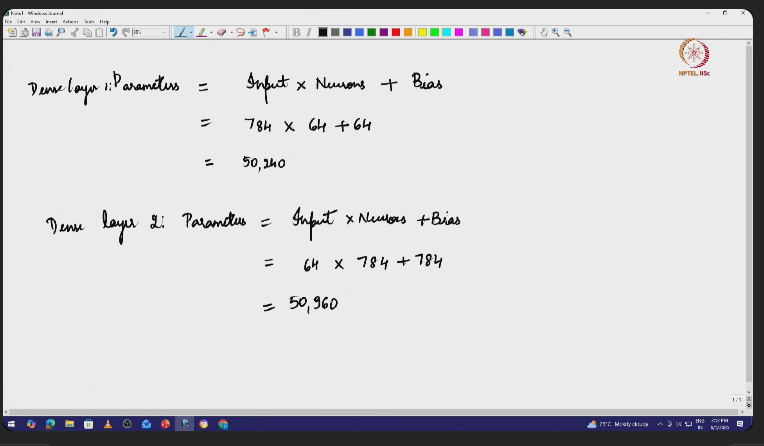

In [ ]:
history = shallow_ae.fit(x_train, x_train, epochs = 5, batch_size = 256, shuffle = True, validation_data = (x_test, x_test)) # mentioned twice each for encoder and decoder

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.2458 - val_loss: 0.1648
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.1456 - val_loss: 0.1277
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.1188 - val_loss: 0.1087
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.1042 - val_loss: 0.0977
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0950 - val_loss: 0.0904


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


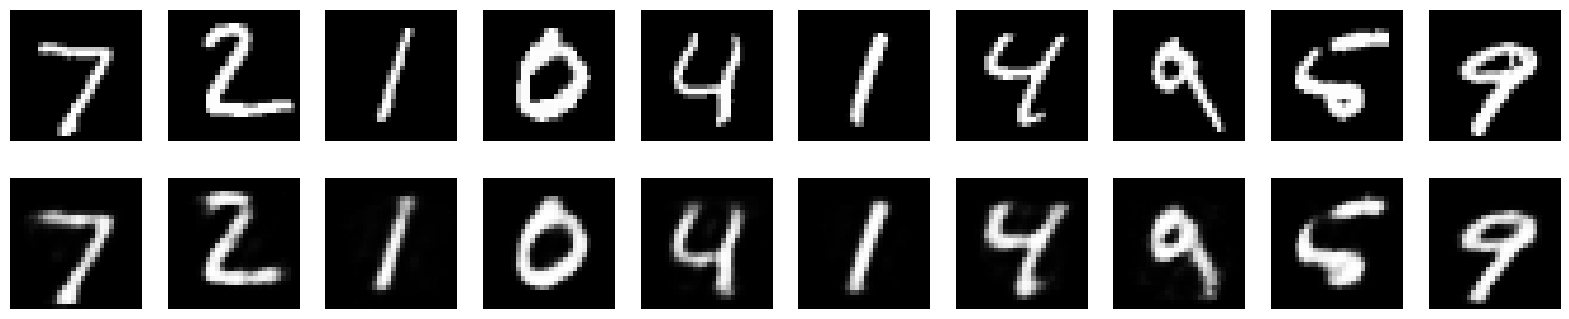

In [ ]:
decoded_imgs = shallow_ae.predict(x_test)

n = 10

plt.figure(figsize = (20, 4))

for i in range(n):

    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap = 'gray')
    plt.axis('off')

    ax = plt.subplot(2, n, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap = 'gray')
    plt.axis('off')

plt.show()

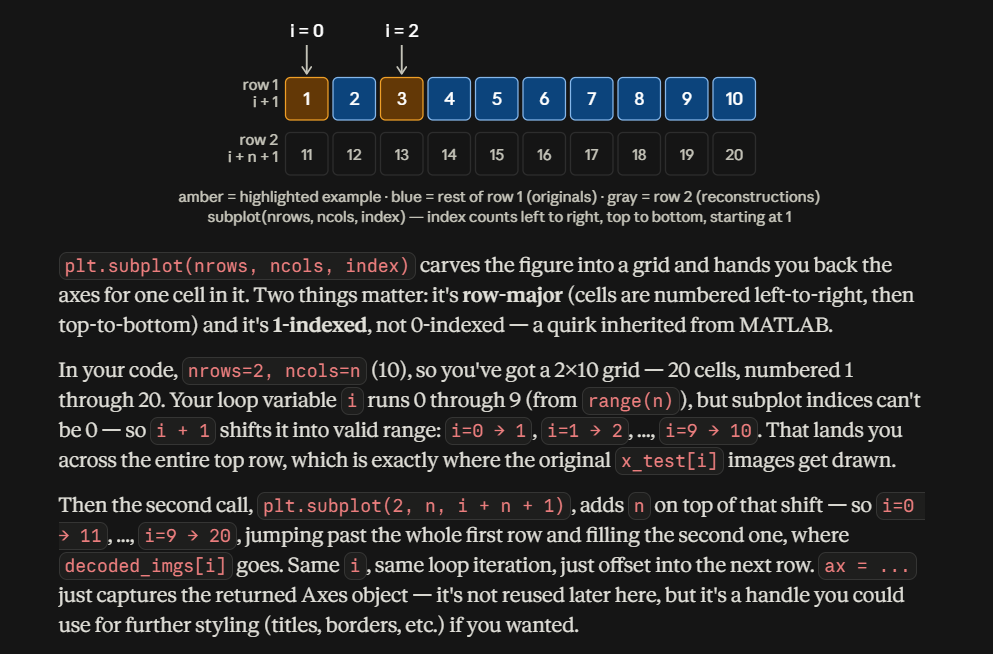

2. Deep Autoencoder

In [ ]:
input_img = Input(shape = (784, ))

encoded = Dense(256, activation = 'relu')(input_img)
encoded = Dense(128, activation = 'relu')(encoded)
encoded = Dense(64, activation = 'relu')(encoded)

decoded = Dense(128, activation = 'relu')(encoded)
decoded = Dense(256, activation = 'relu')(decoded)
decoded = Dense(784, activation = 'sigmoid')(decoded)

deep_ae = Model(input_img, decoded)

deep_ae.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
)

deep_ae.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 784)            │       201,488 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 484,944 (1.85 MB)

 Trainable params: 484,944 (1.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
deep_ae.fit(
    x_train,
    x_train,
    epochs = 5,
    batch_size = 256,
    validation_data = (x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 39ms/step - loss: 0.2139 - val_loss: 0.1381
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.1231 - val_loss: 0.1105
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - loss: 0.1062 - val_loss: 0.1003
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.0984 - val_loss: 0.0943
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0938 - val_loss: 0.0924


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


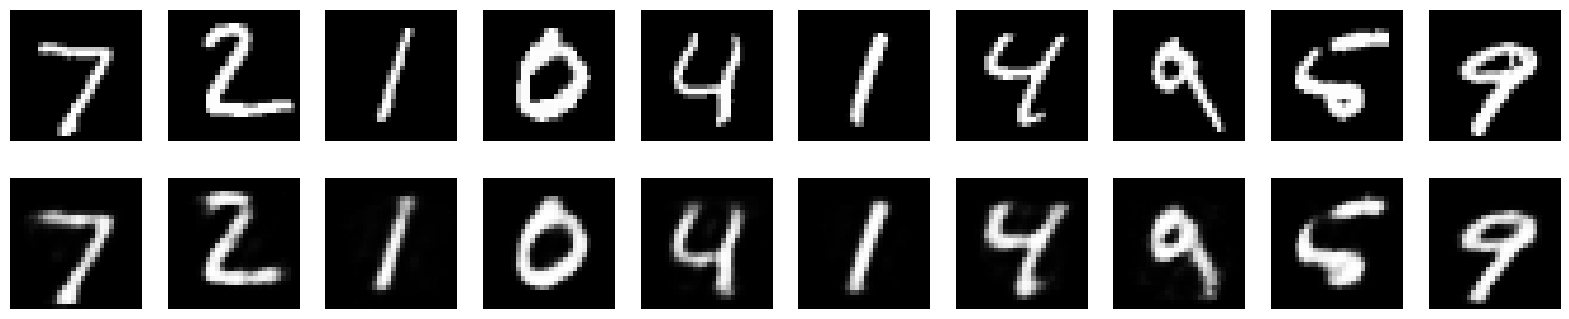

In [ ]:
decoded_imgs = shallow_ae.predict(x_test)

plt.figure(figsize = (20, 4))

for i in range(n):

    ax = plt.subplot(2, 10, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap = 'gray')
    plt.axis('off')

    ax = plt.subplot(2, 10, i + n + 1)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap = 'gray')
    plt.axis('off')

plt.show()

3. Sparse Autoencoder

In [7]:
from tensorflow.keras import regularizers
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model

input_img = Input(shape = (784, ))

encoded = Dense(64, activation = 'relu', activity_regularizer = regularizers.l1(1e-4))(input_img)
decoded = Dense(784, activation = 'sigmoid')(encoded)

sparse_ae = Model(input_img, decoded)

sparse_ae.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
)

sparse_ae.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 784)            │        50,960 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,200 (395.31 KB)

 Trainable params: 101,200 (395.31 KB)

 Non-trainable params: 0 (0.00 B)

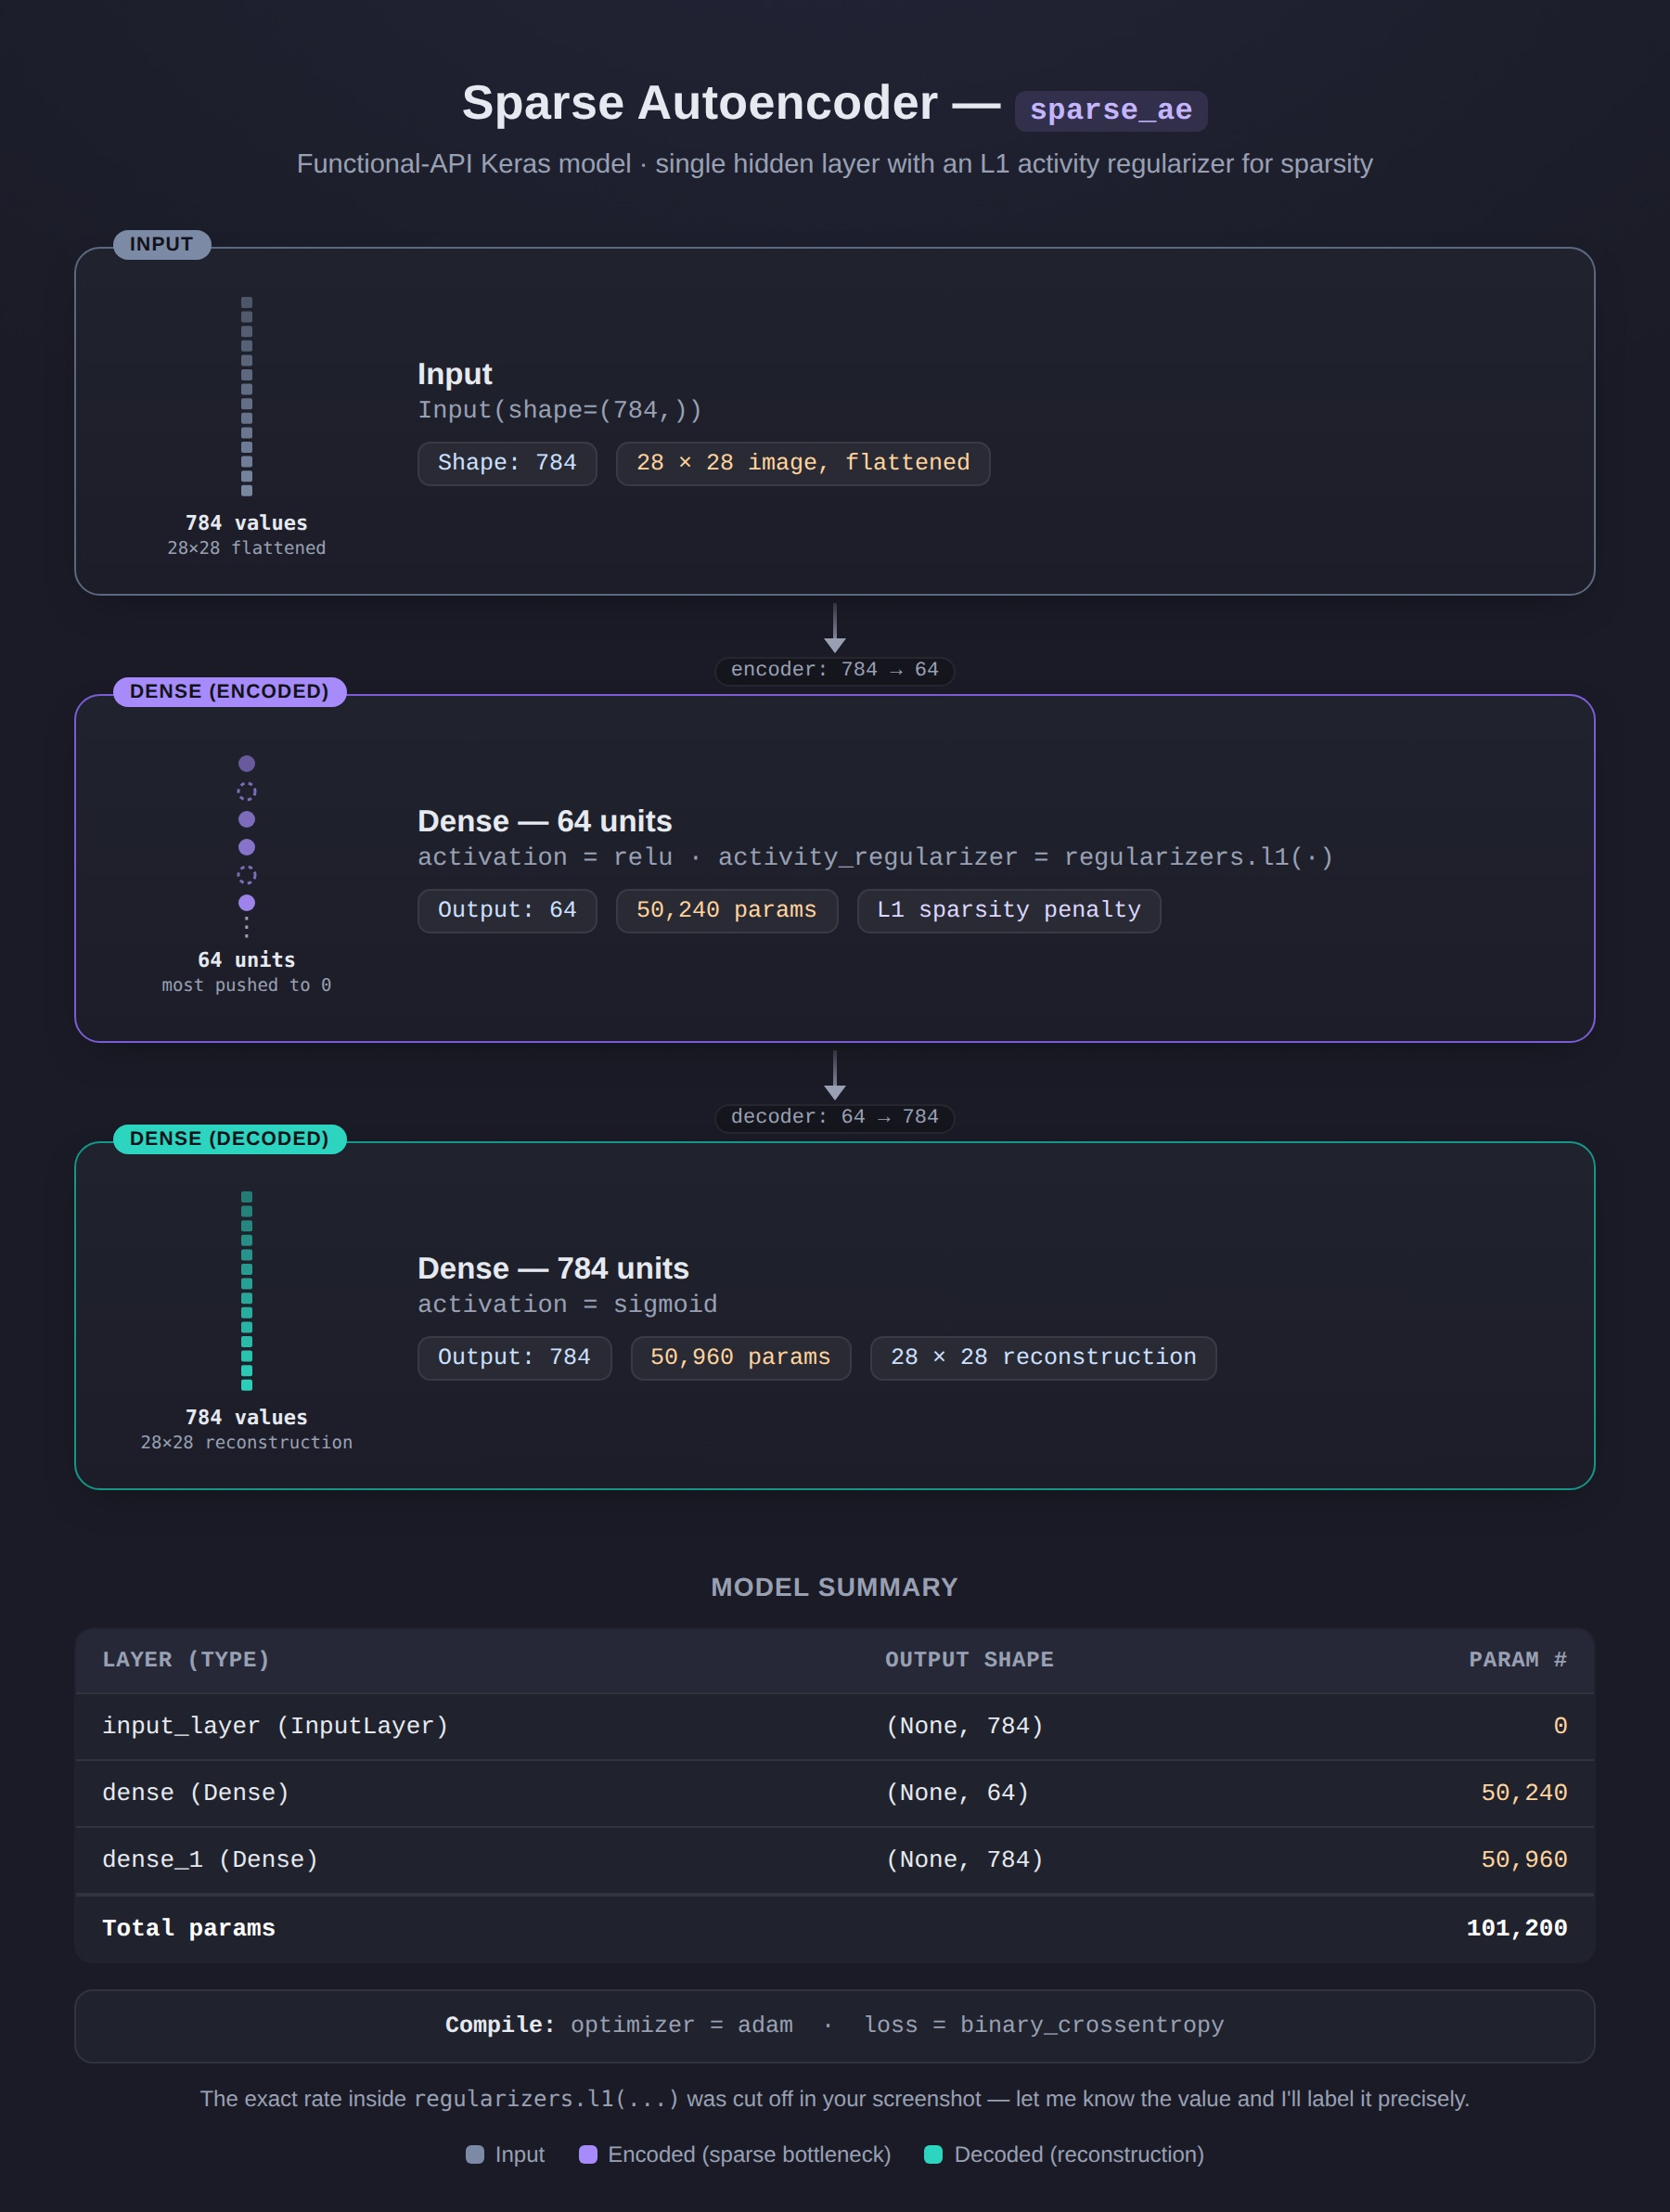

In [10]:
sparse_ae.fit(
    x_train,
    x_train,
    epochs = 5,
    batch_size = 256,
    validation_data = (x_test, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.6568 - val_loss: 0.6155
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.5832 - val_loss: 0.5535
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.5275 - val_loss: 0.5038
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.4827 - val_loss: 0.4638
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.4466 - val_loss: 0.4314


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


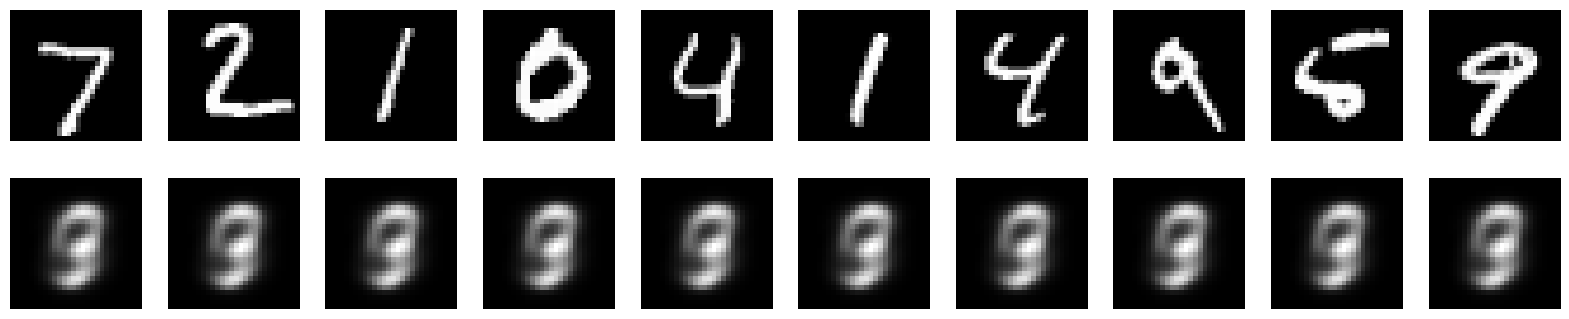

In [13]:
decoded_imgs = sparse_ae.predict(x_test)

plt.figure(figsize = (20, 4))

for i in range(10):

  ax = plt.subplot(2, 10, i + 1)
  plt.imshow(x_test[i].reshape(28, 28), cmap = 'gray')
  plt.axis('off')

  ax = plt.subplot(2, 10, i + 11)
  plt.imshow(decoded_imgs[i].reshape(28, 28), cmap = 'gray')
  plt.axis('off')

plt.show()

4. Denoising Autoencoder

In [14]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor*np.random.normal(
    loc = 0.0, # mean value
    scale = 1.0, # standard deviation
    size = x_train.shape
)

x_test_noisy = x_test + noise_factor*np.random.normal(
    loc = 0.0,
    scale = 1.0,
    size = x_test.shape
)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

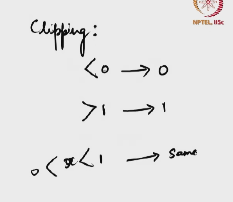

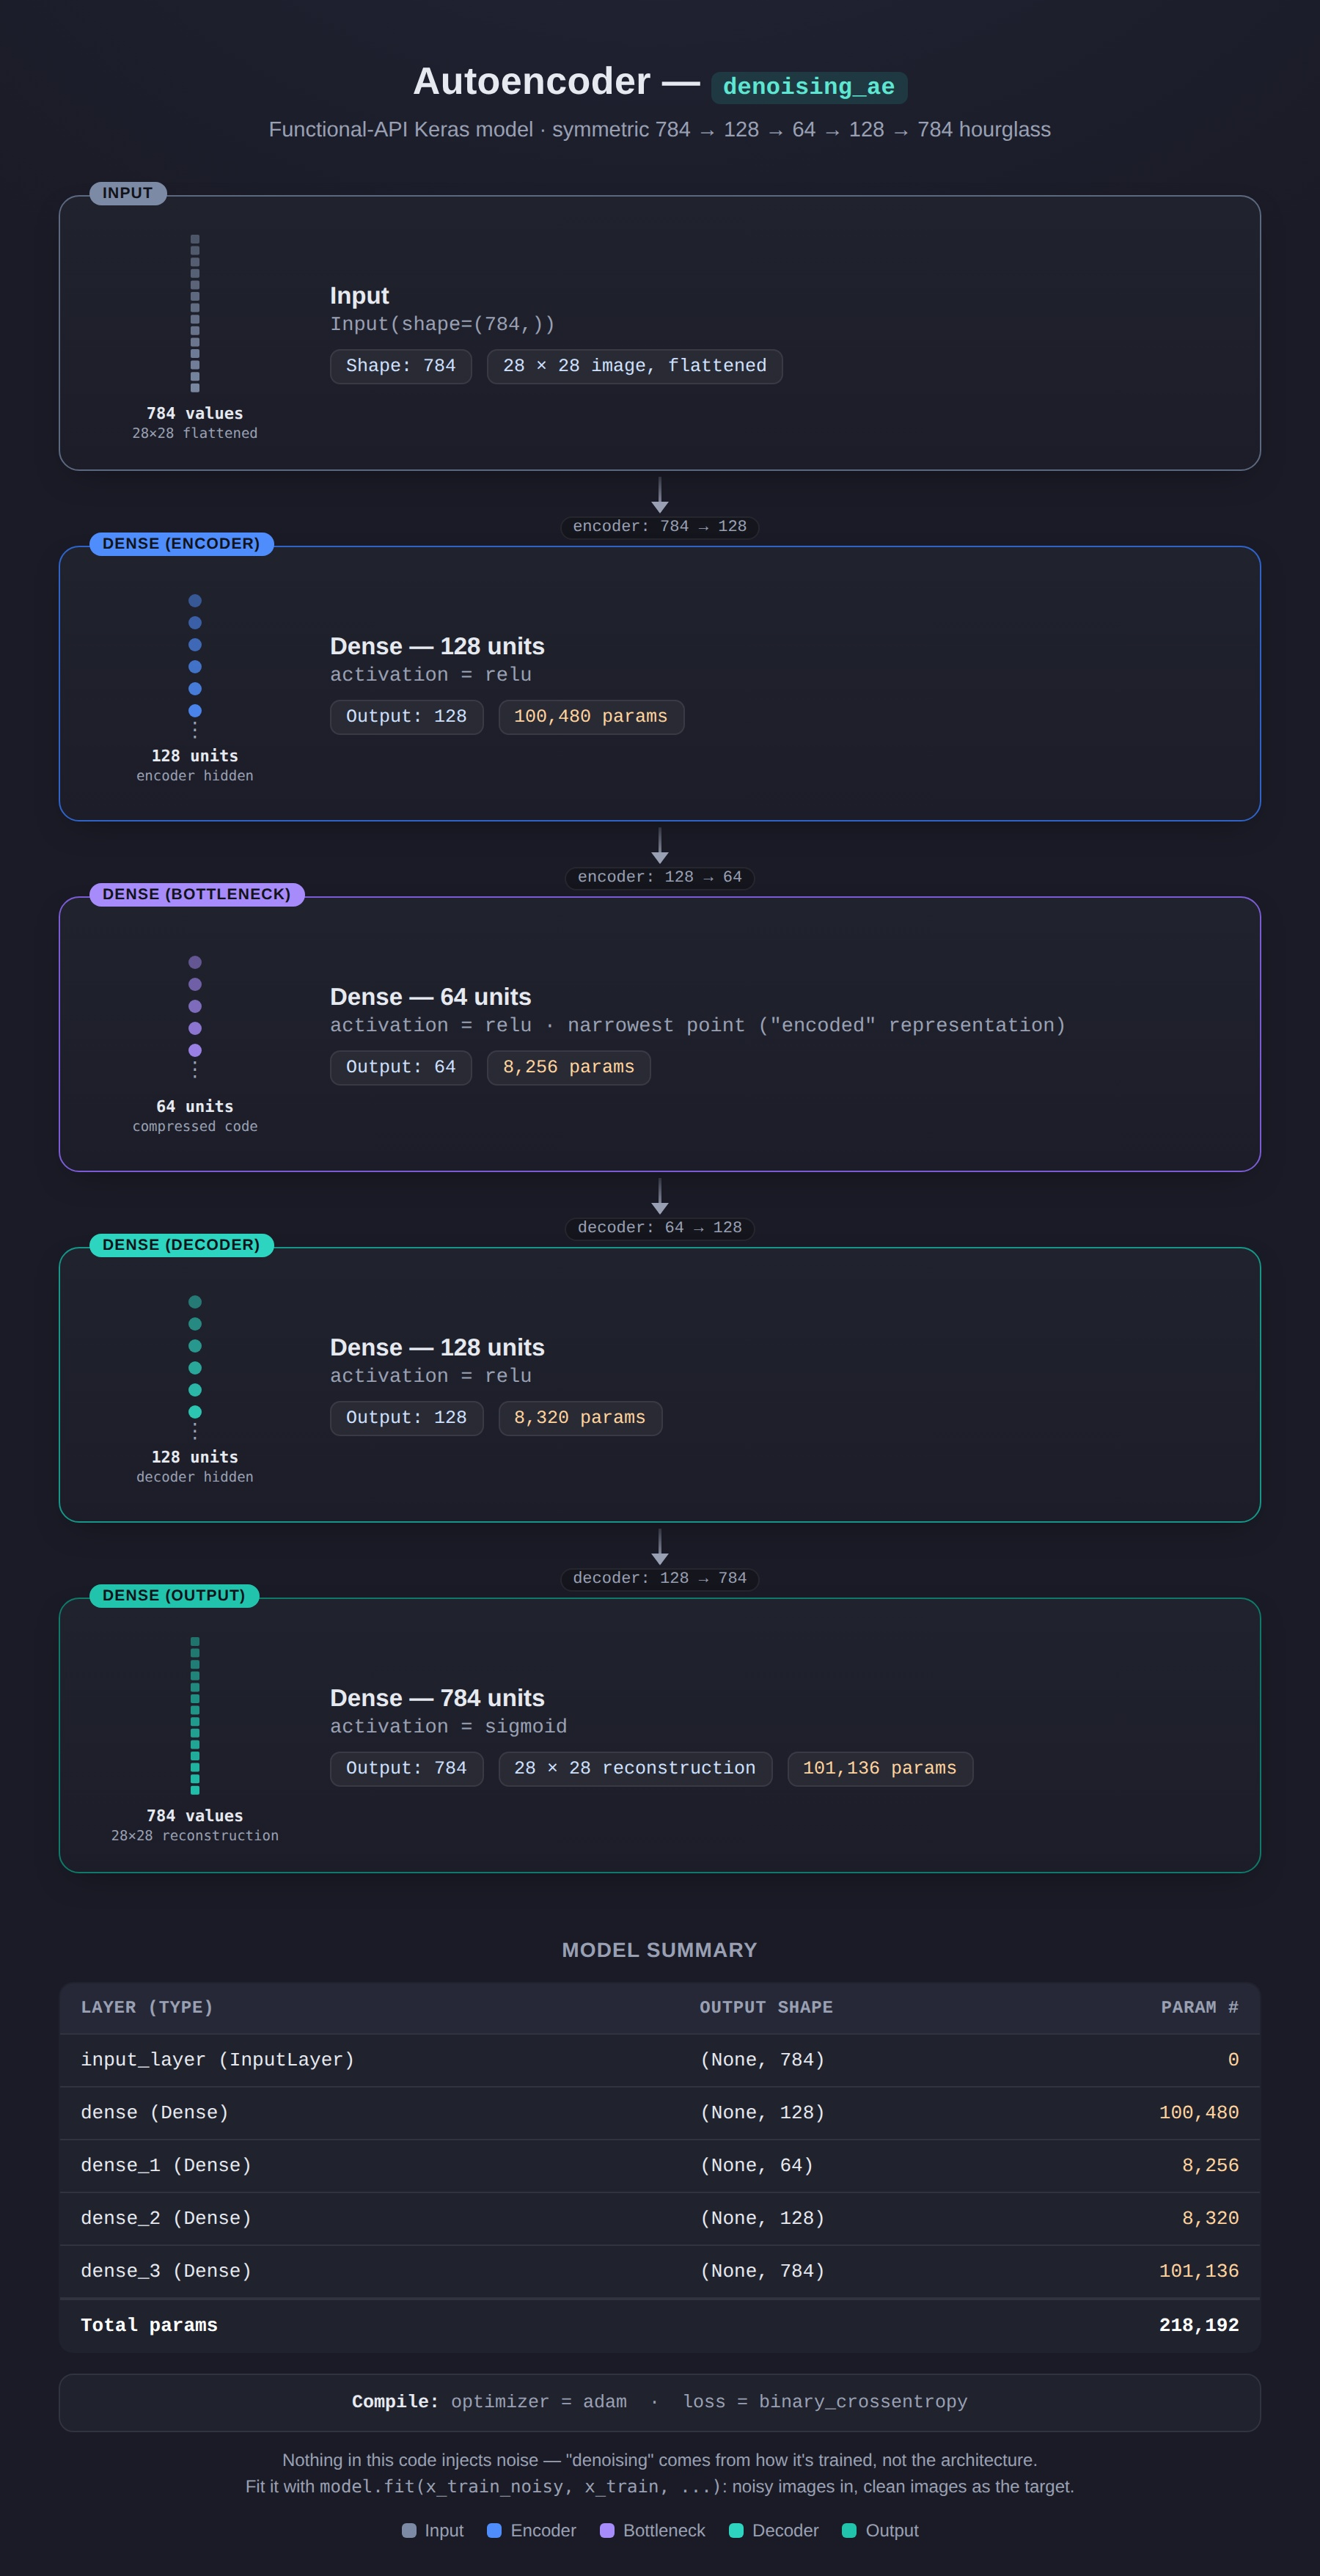

In [15]:
input_img = Input(shape = (784, ))

encoded = Dense(128, activation = 'relu')(input_img)
encoded = Dense(64, activation = 'relu')(encoded)

decoded = Dense(128, activation = 'relu')(encoded)
decoded = Dense(784, activation = 'sigmoid')(decoded)

denoising_ae = Model(input_img, decoded)

denoising_ae.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
)

In [16]:
denoising_ae.fit(
    x_train_noisy,
    x_train,
    epochs = 5,
    batch_size = 256,
    validation_data = (x_test_noisy, x_test)
)

Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.2514 - val_loss: 0.1861
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.1677 - val_loss: 0.1546
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1494 - val_loss: 0.1434
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.1411 - val_loss: 0.1365
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.1353 - val_loss: 0.1324


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


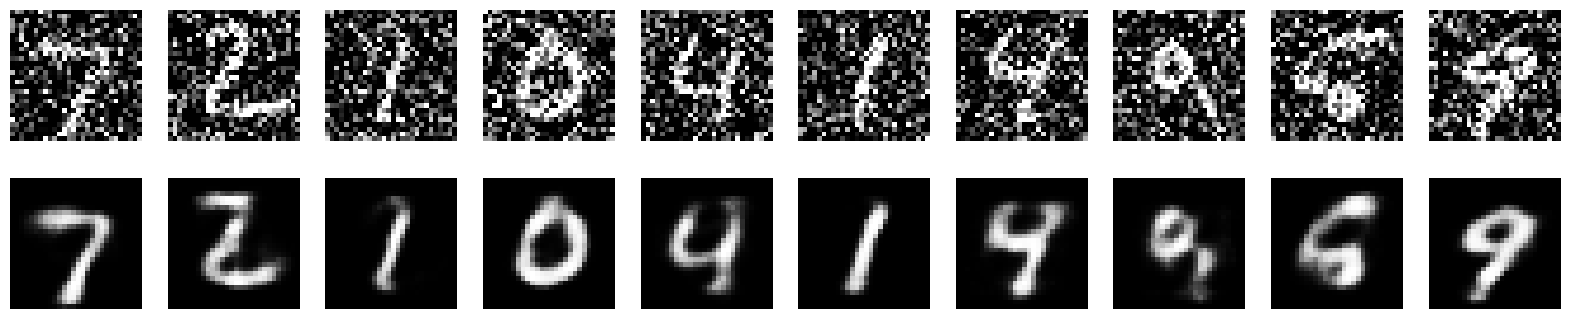

In [18]:
decoded_imgs = denoising_ae.predict(x_test_noisy)

plt.figure(figsize = (20, 4))

for i in range(10):
  ax = plt.subplot(2, 10, i + 1)
  plt.imshow(x_test_noisy[i].reshape(28, 28), cmap = 'gray')
  plt.axis('off')

  ax = plt.subplot(2, 10, i + 11)
  plt.imshow(decoded_imgs[i].reshape(28, 28), cmap = 'gray')
  plt.axis('off')

plt.show()